# Проект 3 модуля: предсказание возраста посетителей сайтов для компании «Йети»

**Выполнил:** Артем Буров  
**Группа:** DS12  
**Дата:** 26 июня 2026  
**Ссылка на GitHub:** https://github.com/TemaQDX/project_module_03_yeti
___

## Описание задачи

**IT‑компания «Йети»**, управляющая группой популярных интернет‑сервисов, получает значительную часть дохода от контекстной рекламы. Чтобы эффективно таргетировать объявления, компания использует демографический таргетинг — в том числе по возрасту. При этом паспортные данные пользователей не задействуются: возраст определяют на основе анализа поведения в цифровой среде.

**Задача** — разработать модель машинного обучения, которая по логам посещений сайтов будет автоматически определять возрастную категорию пользователя. В логах содержатся данные о том, какие категории сайтов посещал пользователь, с какой частотой и в какое время.

Корректное определение возрастной категории критически важно для эффективности рекламных кампаний. Например, яркую рекламу игрового гаджета нужно показывать зумерам, а рекламу семейного отпуска — молодым родителям. Если таргетинг будет неточным, бюджет на рекламу расходуется впустую, конверсия падает, а пользователи видят нерелевантные объявления. Кроме того, правильная сегментация позволяет избежать показа рекламы для взрослых несовершеннолетним. Результат работы модели ляжет в основу реализации маркетинговых стратегий и поможет существенно повысить релевантность рекламных показов.
___

## Выбор метрик

1. В качестве основной метрики используется `F1-мера`.  
Значение F1-меры лучшей модели должно быть **не меньше 0.75** и на кросс-валидации по обучающей выборке, и на тестовой выборке. В этом случае модель можно рекомендовать к внедрению.

2. Вспомогательные метрики качества: `precision` и `recall`.  
Модель нужно оценить одинаково по всем классам с использованием макро-усреднения.

___

## Описание данных

Данные представлены в нескольких CSV-файлах, полученных из разных источников.  
Необходимо их проанализировать, собрать в единую таблицу и построить модель с максимально полным набором признаков.  

#### 1. Таблица `ds_s13_users` содержит информацию о возрастной категории пользователя:  
`user_id` — уникальный идентификатор пользователя.  
`age_category` — возрастная категория пользователя, этот показатель модель должна научиться предсказывать.  
Содержит следующие категории:
- 0: младше 18;
- 1: 18-25 лет;
- 2: 26-40 лет;
- 3: 41-55 лет;
- 4: 56+ лет.


#### 2. Лог посещений сайтов `ds_s13_visits.csv` похож на данные сервиса веб-аналитики «Яндекс Метрика».  
Предназначен для сбора и анализа информации об активности пользователей разных сайтов. В целях защиты персональных данных заменить в логах все URL на анонимизированную категорию сайта, а вместо точного времени использовать время суток.  
Признаки в датасете:  
`date` — дата посещения сайта.  
`daytime` — анонимизированное время посещения сайта. Категории: утро, день, вечер, ночь.  
`session_id` — уникальный идентификатор сессии. Сессия — это последовательность действий пользователя на сайте, которая начинается при первом взаимодействии с ресурсом и завершается по правилам тайм-аута или смены условий.  
`user_id` — уникальный идентификатор пользователя.  
`website_category` — анонимизированная категория сайта. В лог включены несколько десятков категорий, которые позволяют эффективно сегментировать аудиторию. Это позволяет сократить пространство признаков модели без потери её качества.  

#### 3. Таблица `ads_activity`
Активность взаимодействия пользователя с рекламными объявлениями — важный показатель, связанный с возрастом:  
`user_id` — уникальный идентификатор пользователя.  
`ads_activity` — характеристика CTR, выраженная одним из значений: очень редко, редко, умеренно, часто, очень часто.  

#### 4. Таблица `surf_depth`
В таблице содержится два признака:  
`user_id` — уникальный идентификатор пользователя.  
`surf_depth` — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории поверхностно, средне, глубоко.  

#### 5. Таблица `primary_device`
Таблица содержит два признака:  
`user_id` — уникальный идентификатор пользователя.  
`primary_device` — информация о типе основного устройства пользователя для выхода в Интернет.

#### 6. Таблица `cloud_usage`
Использование облачных технологий:  
`user_id` — уникальный идентификатор пользователя;  
`cloud_usage` — True означает, что пользователь обращается к облачным ресурсам типа Яндекс 360 прямо или через посещаемые сайты.
___

## Структура проекта

### 1. Подготовка среды и библиотек
___

## 1. Подготовка среды и библиотек

In [ ]:
# Загружаем базовые библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Проверка наличия jinja2 для отражения тепловой карты корреляций
try:
    import jinja2
except:
    %pip install jinja2

# Загружаем библиотеку для расчёта коэффициента корреляции Phik
try:
    from phik import phik_matrix
except:
    %pip install phik
    from phik import phik_matrix

# Предобрабока данных
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.pipeline import Pipeline
# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest, VarianceThreshold, SequentialFeatureSelector, RFE

# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from category_encoders import LeaveOneOutEncoder
# from sklearn.model_selection import cross_validate, StratifiedKFold

# Загружаем модели
# from sklearn.dummy import DummyClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC

# Модули для построения диаграммы калибровки
# from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
# from sklearn.frozen import FrozenEstimator

# Метрики
# from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, precision_recall_curve, brier_score_loss, log_loss

# Системные библиотеки, настройки отображения датафреймов и предупредительных сообщений
# import joblib
import os
import warnings

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning) 

path = os.getcwd()
RANDOM_SEED = 555

In [2]:
# Подготовка функций

# =========================
# Функция оптимизации датафрейма

def optimize_dataframe(df):
    dataset_cols_float = df.select_dtypes(include=['float64', 'float32']).columns.tolist()
    dataset_cols_int = df.select_dtypes(include=['int64', 'int32']).columns.tolist()

    for col in dataset_cols_float:
        df[col] = pd.to_numeric(df[col], downcast='float')

    for col in dataset_cols_int:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    return df

# Подготавливаем функции визуализации данных и расчета метрик

# =========================
# bar chart

def plot_bar_chart(
    data,
    figsize=(12, 6),
    xlabel='Категория',
    ylabel='Количество',
    title='Столбчатая диаграмма',
    top_n=5
):

    if not isinstance(data, pd.Series):
        data = pd.Series(data)

    value_counts = data.value_counts().head(top_n)
    value_counts_normalized = data.value_counts(normalize=True).head(top_n)
    total = value_counts.sum()

    plt.figure(figsize=figsize)

    ax = value_counts.plot(
        kind='bar',
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0,
        legend=False,
        title=title
    )

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(value_counts):
        y_offset = 0.001 * total
        ax.text(i, v + y_offset, str(v), ha='center', va='bottom', fontsize=10)

    for i, v in enumerate(value_counts_normalized):
        y_pos = (v * total) / 2
        ax.text(
            i, y_pos, f'{v * 100:.1f}%',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold'
        )

    plt.tight_layout()

    plt.show()


In [3]:
# Загрузка первичных данных

df_users = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_users.csv')
df_visits = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_visits.csv')
df_ads_activity = pd.read_csv('https://code.s3.yandex.net/datasets/ads_activity.csv')
df_surf_depth = pd.read_csv('https://code.s3.yandex.net/datasets/surf_depth.csv')
df_primary_device = pd.read_csv('https://code.s3.yandex.net/datasets/primary_device.csv')
df_cloud_usage = pd.read_csv('https://code.s3.yandex.net/datasets/cloud_usage.csv')

### 1.1 Датасет ds_users

In [4]:
df_users = optimize_dataframe(df_users)
df_users.head()

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


In [5]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int8  
dtypes: int8(1), object(1)
memory usage: 52.1+ KB


In [6]:
df_users.astype('str').describe()

,user_id,age_category
count,5913,5913
unique,5826,5
top,3fb4-b0158c2fc55a76a26265-7a5c374a,4
freq,2,1794


In [ ]:
# Явные дубли присутствуют
df_users.duplicated().sum()

np.int64(87)

In [9]:
# Явные дубли устранены
# Первичный ключ user_id
df_users = df_users.drop_duplicates()
df_users.astype('str').describe()

,user_id,age_category
count,5826,5826
unique,5826,5
top,f545-8c95aefe8d3e5548a689-a5b2fd39,4
freq,1,1766


### 1.2 Датасет df_visits

In [10]:
df_visits = optimize_dataframe(df_visits)
df_visits.head()

,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


In [11]:
df_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB


In [12]:
# Явные дубли в наличии
df_visits.describe()

,date,daytime,session_id,user_id,website_category
count,1065745,1065745,1065745,1065745,1065745
unique,14,4,1049995,5826,20
top,2025-11-13,день,c990d22e-a136-4660-91b2-6f7506c6ab81,5ff2-0a5aa967e353041283b9-ff7929cc,Category 03
freq,76599,389052,2,853,70260


In [13]:
df_visits.duplicated().sum()

np.int64(15750)

In [14]:
# Явные дубли устранены
# Первичный ключ session_id
df_visits = df_visits.drop_duplicates()
df_visits.describe()

,date,daytime,session_id,user_id,website_category
count,1049995,1049995,1049995,1049995,1049995
unique,14,4,1049995,5826,20
top,2025-11-13,день,066e4e02-8c1f-45eb-a50f-178659abe698,5ff2-0a5aa967e353041283b9-ff7929cc,Category 03
freq,75491,383328,1,839,69129


### 1.3 Датасет df_ads_activity

In [15]:
df_ads_activity = optimize_dataframe(df_ads_activity)
df_ads_activity.head()

,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно


In [16]:
df_ads_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   ads_activity  5826 non-null   object
dtypes: object(2)
memory usage: 91.2+ KB


In [17]:
df_ads_activity.describe()

,user_id,ads_activity
count,5826,5826
unique,5593,5
top,f45a-cfe100f3852bd9898527-a7a1b986,умеренно
freq,2,1897


In [ ]:
# Явные дубли присутствют
df_ads_activity.duplicated().sum()

np.int64(233)

In [19]:
# Явные дубли устранены
# Первичный ключ user_id
df_ads_activity = df_ads_activity.drop_duplicates()
df_ads_activity.describe()

,user_id,ads_activity
count,5593,5593
unique,5593,5
top,e318-d8e69c86b543a5fb927c-c36fb6e6,умеренно
freq,1,1824


### 1.4 Датасет df_surf_depth

In [20]:
df_surf_depth = optimize_dataframe(df_surf_depth)
df_surf_depth.head()

,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко


In [21]:
df_surf_depth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB


In [22]:
# Первичный ключ user_id
df_surf_depth.describe()

,user_id,surf_depth
count,5715,5715
unique,5715,3
top,f238-0c4c1e787cce311541b7-736925a0,средне
freq,1,2435


### 1.5 Датасет df_primary_device

In [23]:
df_primary_device = optimize_dataframe(df_primary_device)
df_primary_device.head()

,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК


In [24]:
df_primary_device.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB


In [25]:
# Первичный ключ user_id
df_primary_device.describe()

,user_id,primary_device
count,5669,5669
unique,5669,4
top,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
freq,1,3083


### 1.6 Датасет df_cloud_usage

In [26]:
# Первичный ключ user_id
df_cloud_usage = optimize_dataframe(df_cloud_usage)
df_cloud_usage.head()

,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


In [27]:
df_cloud_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.1+ KB


In [28]:
df_cloud_usage.describe()

,user_id,cloud_usage
count,5680,5680
unique,5680,2
top,a1e4-91c8a52eb855595e653f-298ce305,True
freq,1,2951


## Комментарии по итогам подготовки среды и библиотек

Загружены основные библиотеки, подготовлены функции для использования в ходе всего проекта, заданы константы и сделаны необходимые настройки предупреждений.  

Успешно загружены 6 датасетов: `df_users`, `df_visits`,`df_ads_activity`, `df_surf_depth`, `df_primary_device`, `df_cloud_usage`.  

Пропуски в датасетах отсутсвуют.

Для подготовки полного набора данных признак - целевая переменная необходимо определить первичные и внешние ключи отдельных датасетах, удостоверится в уникальности (устранить дубли) первичном ключе.

1) Датасет `df_users` - содержит данные со значениями целевой переменной **age_category**.  
Состав: 5915 строк с дублями. После устранения дублей получаем первичный ключ **user_id** - 5826 уникальных пользователей.  

2) `df_visits` - лог посещений пользователями ваб-сайтов. **1 065 745** строк, **15 750** явных дублей. Дубли удалены. Первичный уникальный ключ - **session_id** (1 049 995 уникальных записи). Также датасет содержит признаки date (14 уникальных записей), daytime (4 уникальных записи), **user_id** - внешний ключ 5826 записей, website_category (20 уникальных значений).

3) `df_ads_activity`. 5826 записей. Содержал явные дубли. После устранения дублей получен первичный ключ **user_id** (5593 значения) и признак ads_activity с 5 уникальными значениями.

4) Датасет `df_surf_depth`. Не содержит дублей. 5715 записей. Первичный ключ **user_id**, признак surf_depth - 3 уникальных значения.

5) `df_primary_device`: 5569 строк без явных дублей. Первичный ключ **user_id**, признак primary_device имеет 4 уникальных значения.

6) Источник `df_cloud_usage` состоит из 5580 строк. Первичный ключ **user_id**, бинарный признак cloud_usage имеет 2 значения True/False.

Итого: объединение всех 6-ти датасетов будем проводить по ключу **user_id**. Число уникальных записей по первичному ключу совпадает не во всех датасетах, значит будут пропуски при соединении по left join. Нужно определиться с методами их заполнения. Данные логов `df_visits` необходимо сгруппировать и привести к виду, где **user_id** также будет первичным ключом.

____

## 2. Исследовательский анализ данных

### 2.1 Первичный анализ отдельных загруженных датасетов

#### 2.1.1 Датасет с целевой переменной `df_users`

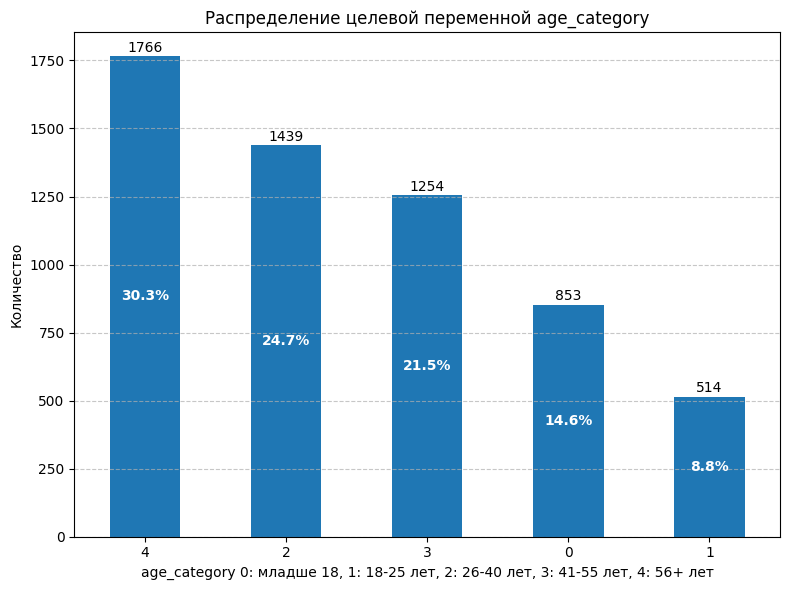

In [29]:
plot_bar_chart(data=df_users['age_category'], figsize=(8, 6), xlabel='age_category 0: младше 18, 1: 18-25 лет, 2: 26-40 лет, 3: 41-55 лет, 4: 56+ лет', ylabel='Количество', title='Распределение целевой переменной age_category')

#### 2.1.2 Датасет `df_ads_activity`

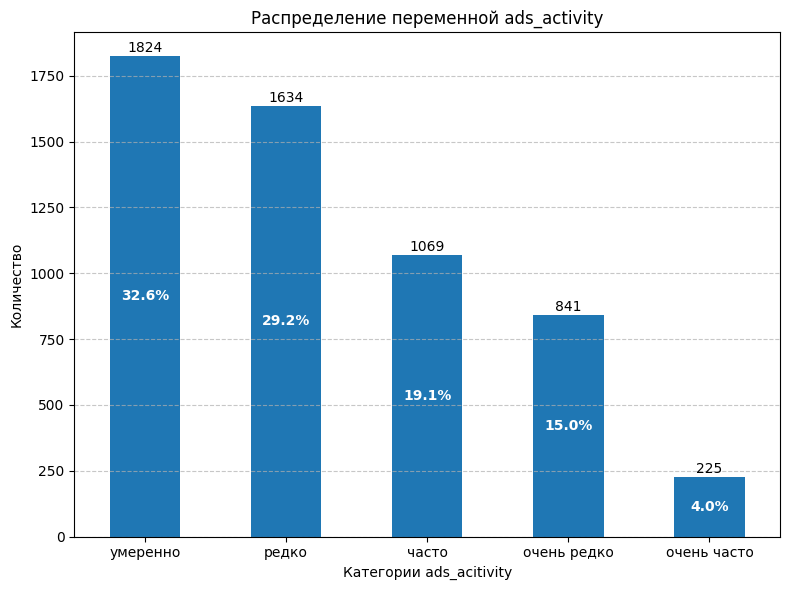

In [30]:
plot_bar_chart(data=df_ads_activity['ads_activity'], figsize=(8, 6), xlabel='Категории ads_acitivity', ylabel='Количество', title='Распределение переменной ads_activity')

#### 2.1.3 Датасет `df_surf_depth`

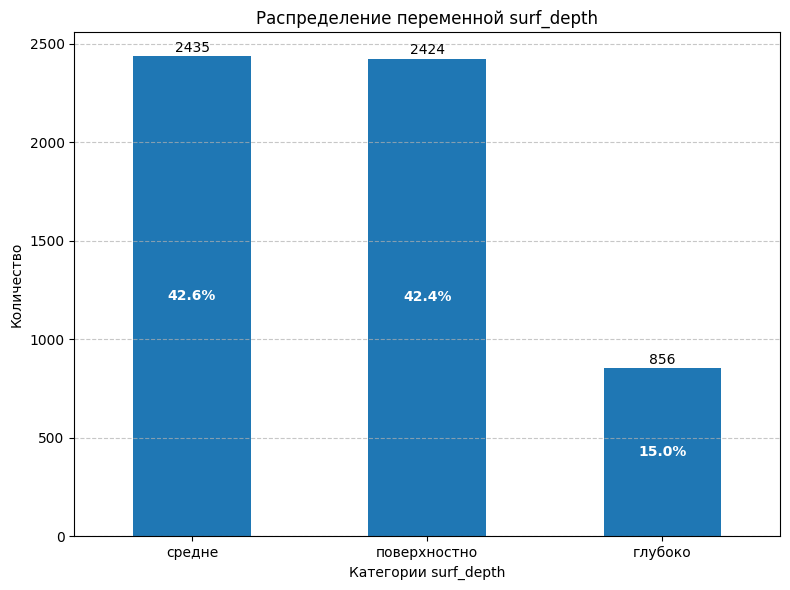

In [31]:
plot_bar_chart(data=df_surf_depth['surf_depth'], figsize=(8, 6), xlabel='Категории surf_depth', ylabel='Количество', title='Распределение переменной surf_depth')

#### 2.1.4 Датасет `df_primary_device`

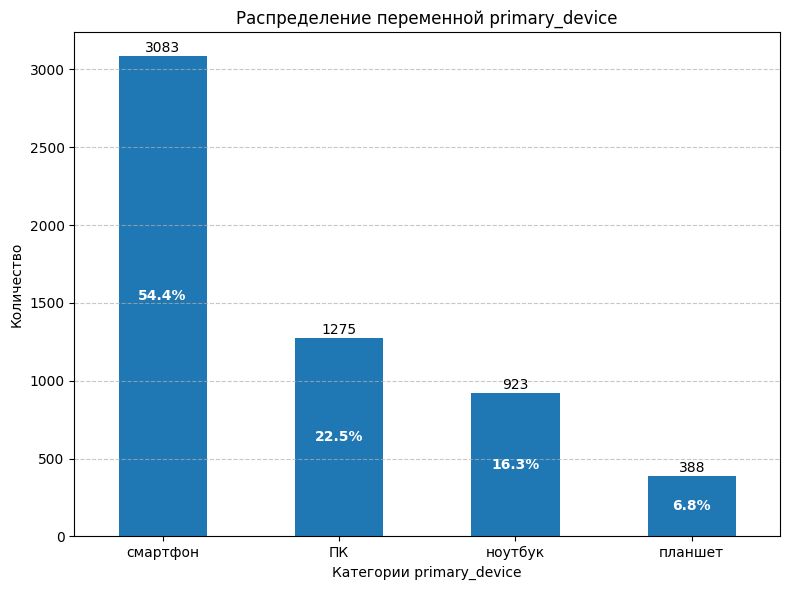

In [32]:
plot_bar_chart(data=df_primary_device['primary_device'], figsize=(8, 6), xlabel='Категории primary_device', ylabel='Количество', title='Распределение переменной primary_device')

#### 2.1.5 Датасет `df_cloud_usage`

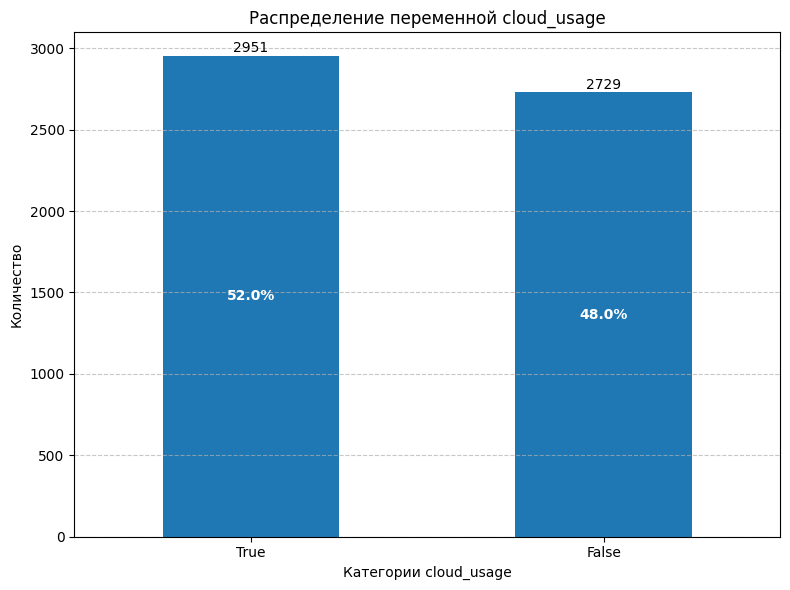

In [33]:
plot_bar_chart(data=df_cloud_usage['cloud_usage'], figsize=(8, 6), xlabel='Категории cloud_usage', ylabel='Количество', title='Распределение переменной cloud_usage')

#### 2.1.6 Датасет `df_visits`

In [34]:
df_visits.describe()

,date,daytime,session_id,user_id,website_category
count,1049995,1049995,1049995,1049995,1049995
unique,14,4,1049995,5826,20
top,2025-11-13,день,066e4e02-8c1f-45eb-a50f-178659abe698,5ff2-0a5aa967e353041283b9-ff7929cc,Category 03
freq,75491,383328,1,839,69129


In [35]:
# Проверяем уникальные значения в столбцах и ищем неявные пропуски
# В анализ добавляем признаки, исключая первичный session_id в внешний ключ user_id 
visits_features = ['date', 'daytime', 'website_category']

for column in visits_features:
    print(f'Уникальные значения в столбце {column}:')
    print(df_visits[column].sort_values().unique())
    print('Число уникальных значений:', df_visits[column].sort_values().nunique())
    print()

Уникальные значения в столбце date:
['2025-11-01' '2025-11-02' '2025-11-03' '2025-11-04' '2025-11-05'
 '2025-11-06' '2025-11-07' '2025-11-08' '2025-11-09' '2025-11-10'
 '2025-11-11' '2025-11-12' '2025-11-13' '2025-11-14']
Число уникальных значений: 14

Уникальные значения в столбце daytime:
['вечер' 'день' 'ночь' 'утро']
Число уникальных значений: 4

Уникальные значения в столбце website_category:
['Category 01' 'Category 02' 'Category 03' 'Category 04' 'Category 05'
 'Category 06' 'Category 07' 'Category 08' 'Category 09' 'Category 10'
 'Category 11' 'Category 12' 'Category 13' 'Category 14' 'Category 15'
 'Category 16' 'Category 17' 'Category 18' 'Category 19' 'Category 20']
Число уникальных значений: 20



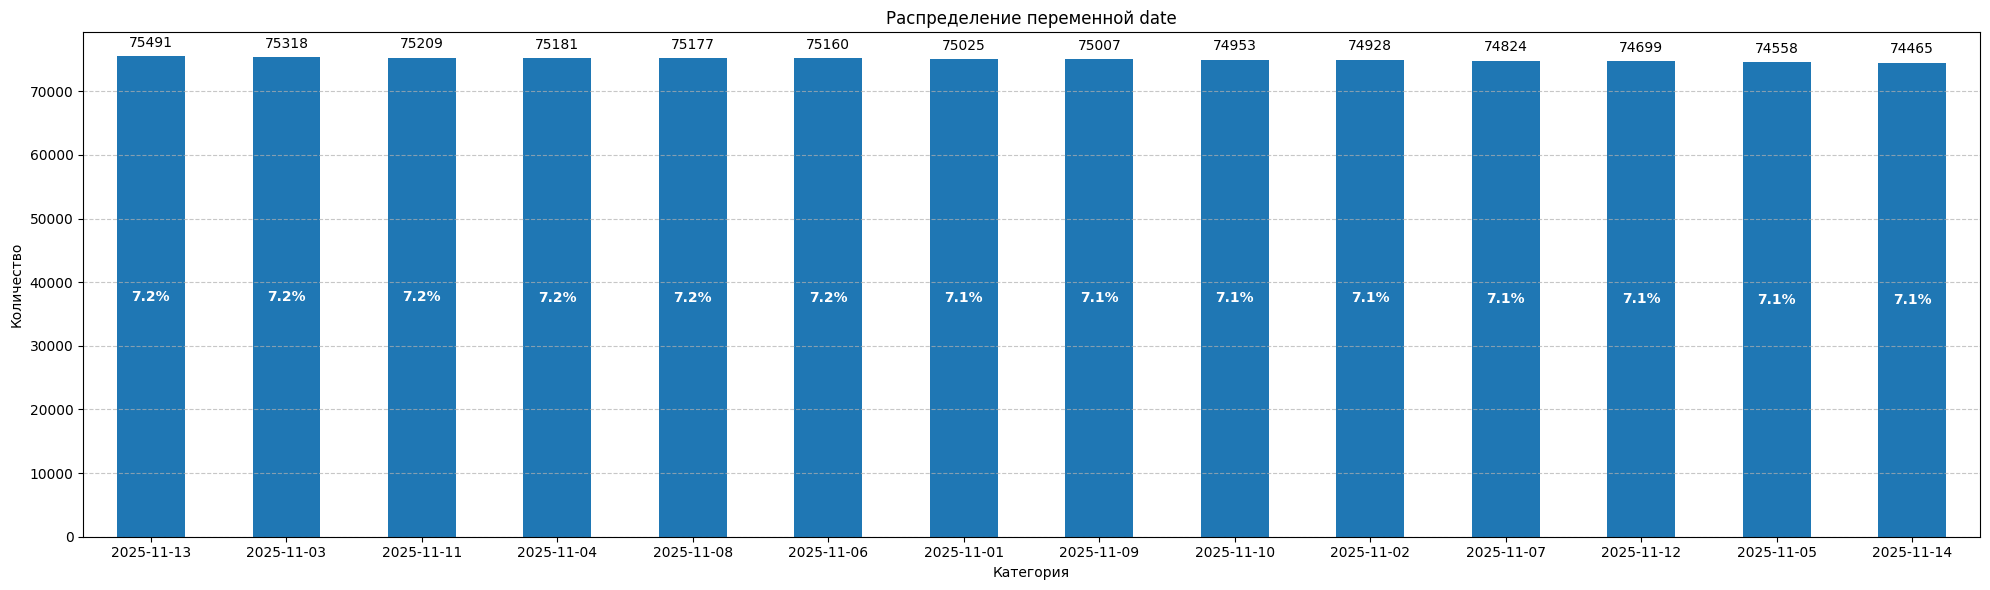

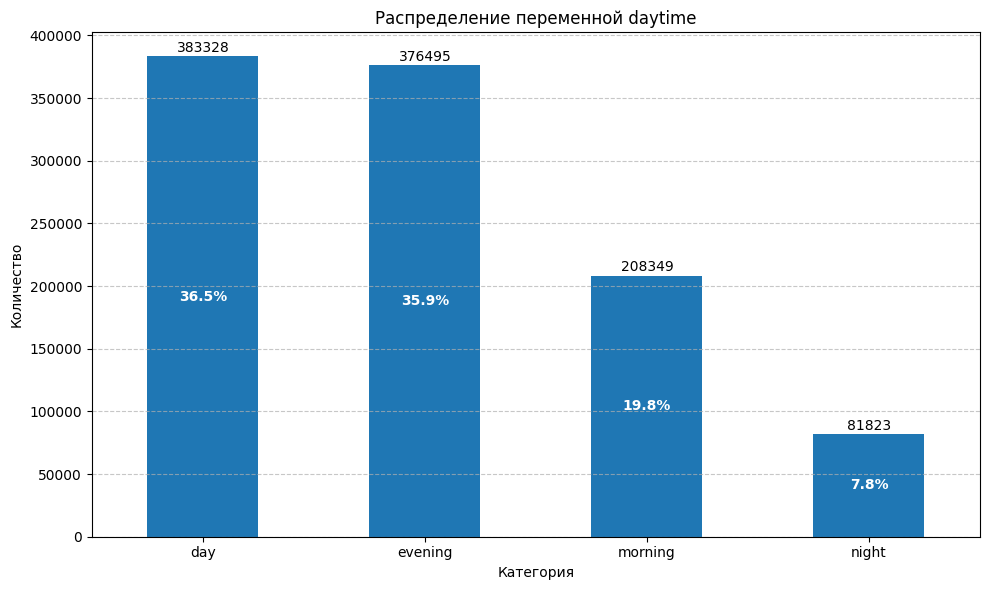

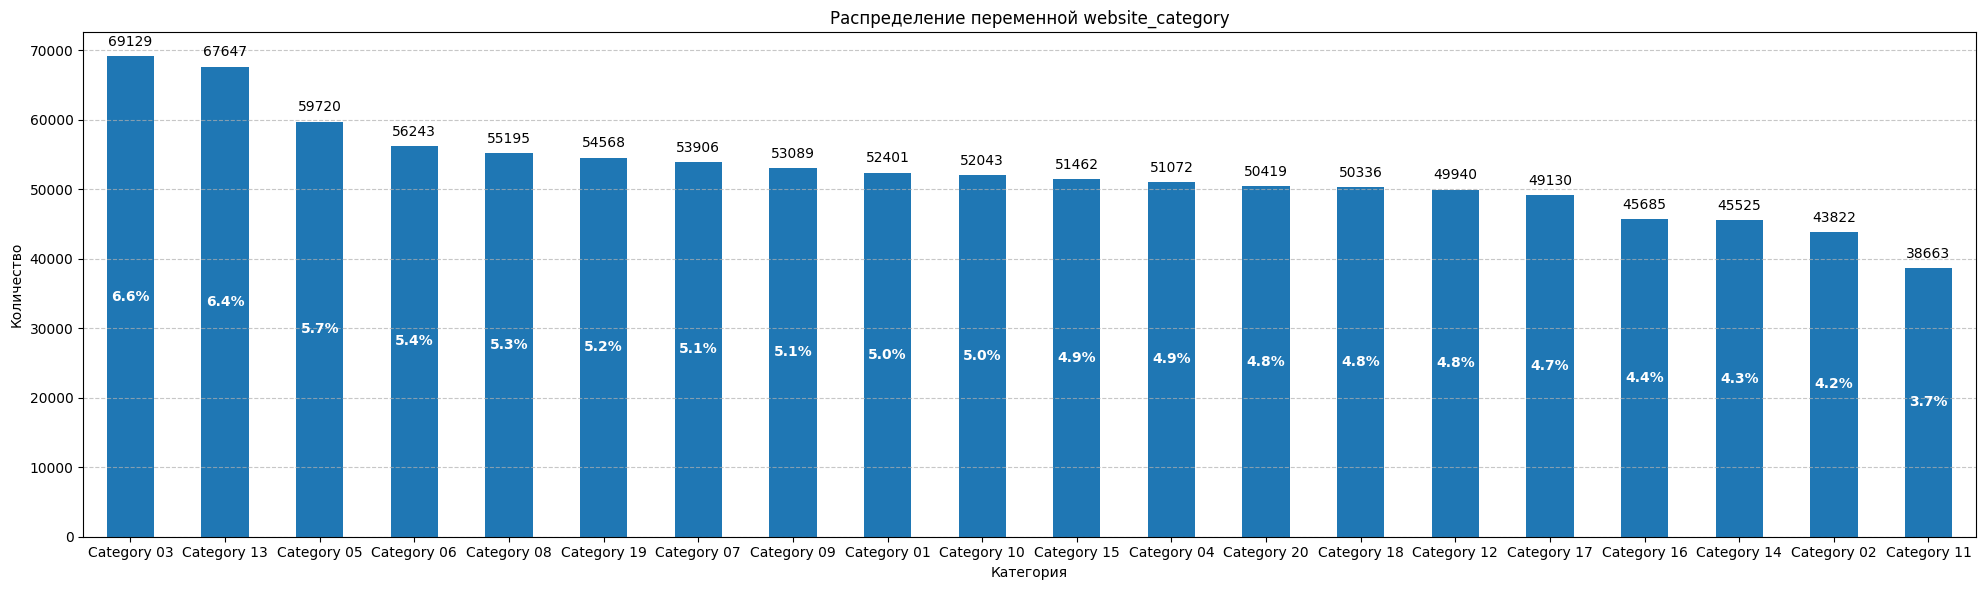

In [53]:
for feature in visits_features:
    if feature == 'daytime':
        top_n = 4
        fs = (10, 6)
    else:
        top_n = 30
        fs = (20, 6)
    plot_bar_chart(data=df_visits[feature], figsize=fs, title=f'Распределение переменной {feature}', top_n=top_n)

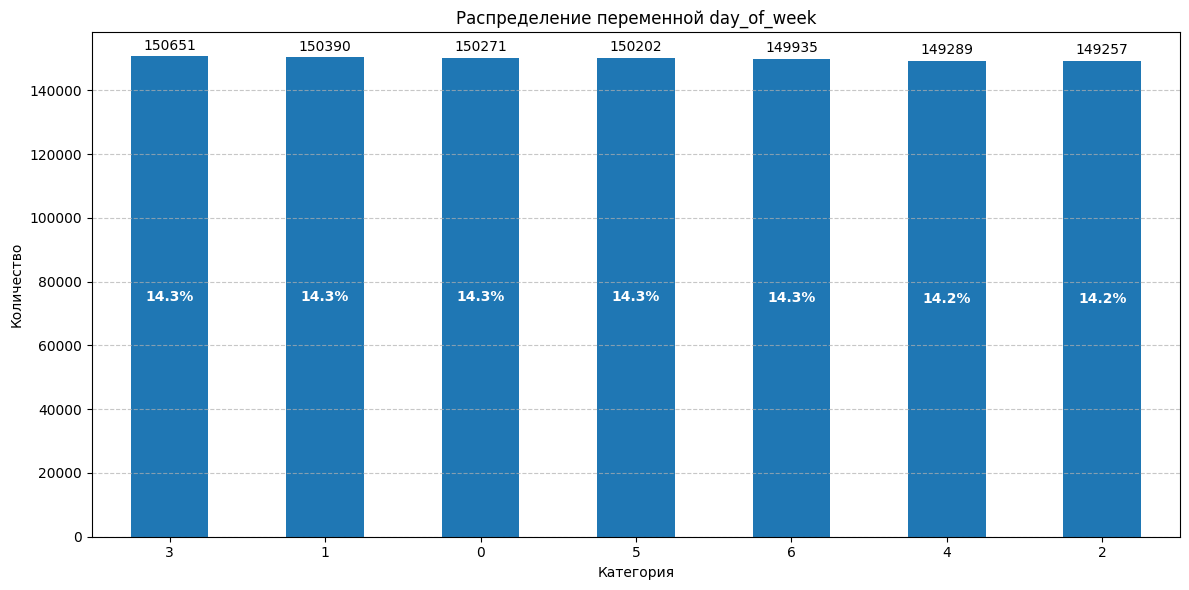

In [52]:
plot_bar_chart(data=pd.to_datetime(df_visits['date']).dt.day_of_week, figsize=(12,6), title=f'Распределение переменной day_of_week', top_n=10) 

In [ ]:
# Значения поля daytime станут новыми признаками, поэтому необходмо заметить русские назания на латиницу
df_visits['daytime'] = df_visits['daytime'].replace({'утро':'morning', 'день':'day', 'вечер':'evening','ночь':'night'})
df_visits

,date,daytime,session_id,user_id,website_category
0,2025-11-01,evening,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,evening,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,evening,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,evening,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,evening,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05
...,...,...,...,...,...
1065740,2025-11-14,morning,672791c6-4f32-4e5a-947a-198a4fd8199a,ffbf-71c28263b860736010d4-a0ee88f3,Category 06
1065741,2025-11-14,morning,67822b34-88ac-40bb-b36a-ab64c3d74333,ffbf-71c28263b860736010d4-a0ee88f3,Category 04
1065742,2025-11-14,morning,98c0ab10-e85f-4c5b-9e41-1171bc118ac5,ffbf-71c28263b860736010d4-a0ee88f3,Category 19
1065743,2025-11-14,morning,9c25daac-741f-4cd3-9dea-31dc187957cd,ffbf-71c28263b860736010d4-a0ee88f3,Category 05


In [ ]:
def build_user_features(df_visits: pd.DataFrame) -> pd.DataFrame:
    """
    Строит агрегированный датасет с первичным ключом user_id.
    
    Возвращает DataFrame с признаками:
      - базовые: total_sessions, avg_sessions_per_day
      - доли по времени суток: share_night, share_morning, share_day, share_evening
      - доли по категориям сайтов: share_cat_Category_X (20 шт.)
      - разнообразие: entropy_category, entropy_daytime
      - флаги: is_high_activity_user
      - отношение: ratio_evening_to_morning
    """
    df = df_visits.copy()

    # Преобразуем date в datetime
    df['date_dt'] = pd.to_datetime(df['date'])

    # -------------------------
    # Базовые агрегаты по user_id
    # -------------------------
    base_agg = (
        df.groupby('user_id')
          .agg(
              total_sessions=('session_id', 'count'),
              days_active=('date_dt', 'nunique')  # считаем уникальные дни автоматически
          )
          .reset_index()
    )
    
    # avg_sessions_per_day: избегаем деления на 0, если вдруг days_active == 0
    base_agg['avg_sessions_per_day'] = (
        base_agg['total_sessions'] / base_agg['days_active'].replace(0, 1)
    )

    # Порог для is_high_activity_user (75 перцентиль total_sessions)
    threshold_75 = base_agg['total_sessions'].quantile(0.75)
    base_agg['is_high_activity_user'] = (base_agg['total_sessions'] > threshold_75).astype(int)

    # Убираем days_active из финального набора — он нужен только для расчёта avg, но сам по себе не несёт информации
    base_agg = base_agg.drop(columns=['days_active'])

    # -------------------------
    # Доли по времени суток (daytime)
    # -------------------------
    time_shares = (
        pd.crosstab(df['user_id'], df['daytime'], values=df['session_id'], aggfunc='count')
        .fillna(0)
    )
    time_shares = time_shares.div(time_shares.sum(axis=1), axis=0)  # нормализация по строкам
    time_shares = time_shares.add_prefix('share_')

    # ratio_evening_to_morning: отношение долей (если morning=0, избегаем деления на 0)
    ratio_evening_morning = (
        time_shares['share_evening'] / time_shares['share_morning'].replace(0, np.nan)
    ).fillna(0).rename('ratio_evening_to_morning')

    # -------------------------
    # Доли по категориям сайтов (website_category)
    # -------------------------
    cat_shares = (
        pd.crosstab(df['user_id'], df['website_category'], values=df['session_id'], aggfunc='count')
        .fillna(0)
    )
    cat_shares = cat_shares.div(cat_shares.sum(axis=1), axis=0)
    cat_shares = cat_shares.add_prefix('share_cat_')

    # -------------------------
    # Энтропия (разнообразие)
    # -------------------------
    def entropy(p: pd.Series) -> float:
        p = p[p > 0]
        if len(p) == 0:
            return 0.0
        return -np.sum(p * np.log2(p))

    entropy_category = cat_shares.apply(entropy, axis=1).rename('entropy_category')
    entropy_daytime = time_shares.apply(entropy, axis=1).rename('entropy_daytime')

    # -------------------------
    # Сборка итогового DataFrame
    # -------------------------
    result = base_agg.merge(time_shares, on='user_id', how='left')
    result = result.merge(cat_shares, on='user_id', how='left')
    result = result.merge(entropy_category, left_on='user_id', right_index=True, how='left')
    result = result.merge(entropy_daytime, left_on='user_id', right_index=True, how='left')
    result = result.merge(ratio_evening_morning, left_on='user_id', right_index=True, how='left')

    # Заполним NaN нулями (на случай пользователей с очень редкими категориями/временными окнами)
    result = result.fillna(0)

    return result


In [64]:
df_user_logs = optimize_dataframe(build_user_features(df_visits))
df_user_logs.head()

,user_id,total_sessions,avg_sessions_per_day,is_high_activity_user,share_day,share_evening,share_morning,share_night,share_cat_Category 01,share_cat_Category 02,share_cat_Category 03,share_cat_Category 04,share_cat_Category 05,share_cat_Category 06,share_cat_Category 07,share_cat_Category 08,share_cat_Category 09,share_cat_Category 10,share_cat_Category 11,share_cat_Category 12,share_cat_Category 13,share_cat_Category 14,share_cat_Category 15,share_cat_Category 16,share_cat_Category 17,share_cat_Category 18,share_cat_Category 19,share_cat_Category 20,entropy_category,entropy_daytime,ratio_evening_to_morning
0,0010-5cf8f6b38a7b6c70a021-009dbcda,546,39.000000,1,0.326007,0.413919,0.164835,0.095238,0.029304,0.000000,0.062271,0.042125,0.032967,0.053114,0.047619,0.075092,0.023810,0.040293,0.056777,0.078755,0.021978,0.034799,0.027473,0.060440,0.051282,0.078755,0.091575,0.091575,4.123766,1.805705,2.511111
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,185,13.214286,0,0.372973,0.275676,0.264865,0.086486,0.081081,0.059459,0.027027,0.037838,0.081081,0.037838,0.048649,0.097297,0.059459,0.059459,0.070270,0.000000,0.064865,0.037838,0.016216,0.043243,0.064865,0.086486,0.005405,0.021622,4.069653,1.856232,1.040816
2,0014-d3032d60979a8d2b3077-f09bdce8,117,8.357142,0,0.384615,0.307692,0.213675,0.094017,0.008547,0.017094,0.034188,0.059829,0.068376,0.051282,0.042735,0.017094,0.034188,0.051282,0.000000,0.059829,0.170940,0.068376,0.059829,0.017094,0.076923,0.025641,0.102564,0.034188,3.944502,1.849845,1.440000
3,001a-eee53e44f848608779b0-78704a67,287,20.500000,1,0.334495,0.414634,0.142857,0.108014,0.066202,0.045296,0.034843,0.076655,0.034843,0.031359,0.041812,0.045296,0.045296,0.041812,0.048780,0.066202,0.000000,0.097561,0.041812,0.031359,0.045296,0.073171,0.073171,0.059233,4.170549,1.802958,2.902439
4,002c-40a064b12e1217e12207-a56eaf3b,490,35.000000,1,0.383673,0.295918,0.251020,0.069388,0.000000,0.053061,0.071429,0.061224,0.040816,0.038776,0.059184,0.018367,0.059184,0.065306,0.038776,0.085714,0.169388,0.000000,0.044898,0.040816,0.034694,0.012245,0.051020,0.055102,3.963736,1.817755,1.178862


In [65]:
df_user_logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   5826 non-null   object 
 1   total_sessions            5826 non-null   int16  
 2   avg_sessions_per_day      5826 non-null   float32
 3   is_high_activity_user     5826 non-null   int8   
 4   share_day                 5826 non-null   float32
 5   share_evening             5826 non-null   float32
 6   share_morning             5826 non-null   float32
 7   share_night               5826 non-null   float32
 8   share_cat_Category 01     5826 non-null   float32
 9   share_cat_Category 02     5826 non-null   float32
 10  share_cat_Category 03     5826 non-null   float32
 11  share_cat_Category 04     5826 non-null   float32
 12  share_cat_Category 05     5826 non-null   float32
 13  share_cat_Category 06     5826 non-null   float32
 14  share_ca

In [68]:
df_user_logs.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,total_sessions,avg_sessions_per_day,is_high_activity_user,share_day,share_evening,share_morning,share_night,share_cat_Category 01,share_cat_Category 02,share_cat_Category 03,share_cat_Category 04,share_cat_Category 05,share_cat_Category 06,share_cat_Category 07,share_cat_Category 08,share_cat_Category 09,share_cat_Category 10,share_cat_Category 11,share_cat_Category 12,share_cat_Category 13,share_cat_Category 14,share_cat_Category 15,share_cat_Category 16,share_cat_Category 17,share_cat_Category 18,share_cat_Category 19,share_cat_Category 20,entropy_category,entropy_daytime,ratio_evening_to_morning
count,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000
mean,180.225712,12.874048,0.248541,0.364961,0.358199,0.198733,0.078108,0.049933,0.041647,0.065480,0.048701,0.057005,0.053715,0.051322,0.052678,0.050884,0.049334,0.036852,0.047742,0.064447,0.043433,0.048679,0.043211,0.046991,0.048007,0.051999,0.047940,3.970255,1.791994,1.902955
std,75.186802,5.369733,0.432204,0.045206,0.048836,0.038134,0.024633,0.031238,0.029358,0.051979,0.027860,0.029300,0.028035,0.029239,0.032203,0.028265,0.028688,0.027020,0.030454,0.057089,0.029823,0.028532,0.028434,0.029080,0.031702,0.028733,0.029135,0.128301,0.054885,0.592909
min,100.000000,7.142857,0.000000,0.217822,0.214286,0.049505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.389503,1.511382,0.611111
25%,124.000000,8.857142,0.000000,0.335058,0.324324,0.172575,0.060606,0.026786,0.018779,0.020000,0.029304,0.036776,0.033898,0.030000,0.029126,0.030422,0.029412,0.016048,0.024845,0.008130,0.020000,0.028846,0.021277,0.025641,0.024540,0.031059,0.026667,3.885660,1.757905,1.470588
50%,167.000000,11.928572,0.000000,0.365385,0.357542,0.196765,0.076142,0.048630,0.039697,0.060241,0.046296,0.055215,0.051282,0.050000,0.050533,0.049417,0.047619,0.033528,0.046403,0.056936,0.041237,0.047619,0.040381,0.045161,0.044329,0.050000,0.045595,3.983219,1.795900,1.833333
75%,213.000000,15.214286,0.000000,0.395664,0.391304,0.223863,0.093407,0.070000,0.060606,0.101695,0.066169,0.075885,0.070866,0.070000,0.074286,0.068801,0.066865,0.054217,0.068182,0.102795,0.062850,0.067227,0.060309,0.064852,0.067797,0.070000,0.066667,4.067505,1.829532,2.222222
90%,273.000000,19.500000,1.000000,0.422184,0.421953,0.250000,0.110220,0.090909,0.081275,0.136229,0.084615,0.095238,0.090909,0.089744,0.095029,0.088235,0.087039,0.072581,0.088465,0.145732,0.083333,0.084841,0.081081,0.086775,0.090239,0.090000,0.087275,4.130758,1.859563,2.666667
95%,322.000000,23.000000,1.000000,0.438393,0.440144,0.264706,0.120871,0.105430,0.094003,0.158416,0.098214,0.108911,0.103448,0.101621,0.108320,0.100426,0.100000,0.085553,0.100636,0.168973,0.095348,0.098837,0.093712,0.100000,0.106236,0.101449,0.100000,4.155951,1.876271,3.000000
99%,438.750000,31.339286,1.000000,0.470216,0.471528,0.290000,0.141728,0.130577,0.118051,0.202756,0.127613,0.133652,0.128713,0.126050,0.134812,0.127033,0.127201,0.112497,0.125512,0.215456,0.120000,0.123155,0.120000,0.123045,0.134615,0.127875,0.125000,4.188829,1.903959,3.636364


## Предобработка данных

## Обучение и оценка базовой модели

## Создание и отбор признаков

## Подбор гиперпараметров моделей

## Подготовка артефактов модели для внедрения

## Выводы о результатах работы